In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

n = 600
brands = np.random.choice(["Toyota","Honda","Ford","BMW","Hyundai"], n, p=[.25,.22,.20,.13,.20])
brand_premium = {"Toyota":0, "Honda":500, "Ford":-500, "BMW":8000, "Hyundai":-1000}
age = np.random.uniform(0, 15, n)
mileage = age * np.random.uniform(8000, 16000, n)
engine = np.random.uniform(1.0, 4.0, n)
fuel = np.random.choice(["Petrol","Diesel","Electric"], n, p=[.50,.35,.15])
fuel_premium = np.where(fuel=="Electric", 4000, np.where(fuel=="Diesel", 800, 0))
base_price = 28000 - age*1400 - mileage*0.04 + engine*1500
price = base_price + np.array([brand_premium[b] for b in brands]) + fuel_premium + np.random.normal(0,1200,n)
price = np.clip(price, 1500, None)

veh_df = pd.DataFrame({
    "brand": brands, "age_years": age, "mileage_km": mileage,
    "engine_size_L": engine, "fuel_type": fuel, "price": price
})
display(veh_df.head())

,brand,age_years,mileage_km,engine_size_L,fuel_type,price
0,Honda,2.534026,35643.876468,3.869504,Petrol,30602.788570
1,Hyundai,4.178855,34252.801971,3.212525,Petrol,25338.685559
2,BMW,2.655157,21711.190182,2.059754,Petrol,35324.246749
3,Ford,1.330538,14088.909617,1.889607,Petrol,26268.953669
4,Toyota,1.809538,21550.052164,2.049110,Diesel,29932.641937


In [2]:
print("Dataset shape:", veh_df.shape)
display(veh_df.describe(include="all"))

Dataset shape: (600, 6)


,brand,age_years,mileage_km,engine_size_L,fuel_type,price
count,600,600.000000,600.000000,600.000000,600,600.000000
unique,5,NaN,NaN,NaN,3,NaN
top,Toyota,NaN,NaN,NaN,Petrol,NaN
freq,155,NaN,NaN,NaN,301,NaN
mean,NaN,7.429401,87965.620524,2.506046,NaN,19460.085411
std,NaN,4.364389,55058.973795,0.855447,NaN,8891.300561
min,NaN,0.069480,837.785557,1.004695,NaN,1500.000000
25%,NaN,3.491592,41344.299818,1.779828,NaN,12506.279639
50%,NaN,7.504779,82342.731875,2.543861,NaN,19810.074330
75%,NaN,11.216579,128616.779966,3.238956,NaN,26562.137624


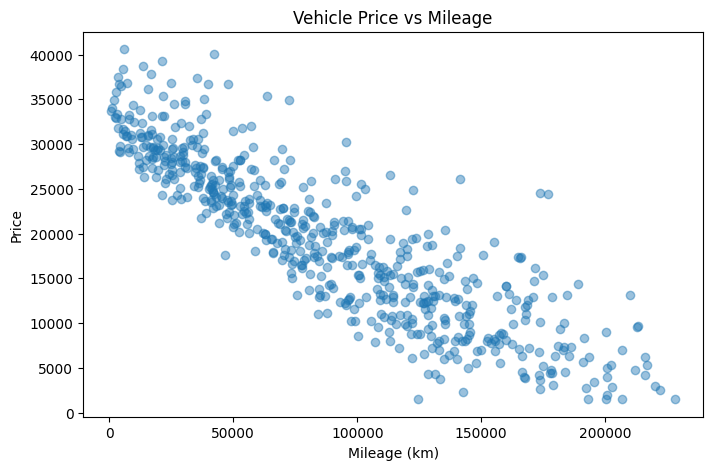

In [3]:
plt.figure(figsize=(8,5))
plt.scatter(veh_df["mileage_km"], veh_df["price"], alpha=0.45)
plt.xlabel("Mileage (km)")
plt.ylabel("Price")
plt.title("Vehicle Price vs Mileage")
plt.show()

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = veh_df.drop(columns="price")
y = veh_df["price"]

num_feats = ["age_years", "mileage_km", "engine_size_L"]
cat_feats = ["brand", "fuel_type"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_feats),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats)
])

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

results, predictions = {}, {}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    predictions[name] = preds
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds) ** 0.5,
        "R2": r2_score(y_test, preds)
    }

results_df = pd.DataFrame(results).T
display(results_df.round(3))

,MAE,RMSE,R2
Linear Regression,935.269,1154.618,0.983
Random Forest,1106.226,1462.223,0.973
Gradient Boosting,1042.507,1323.045,0.978


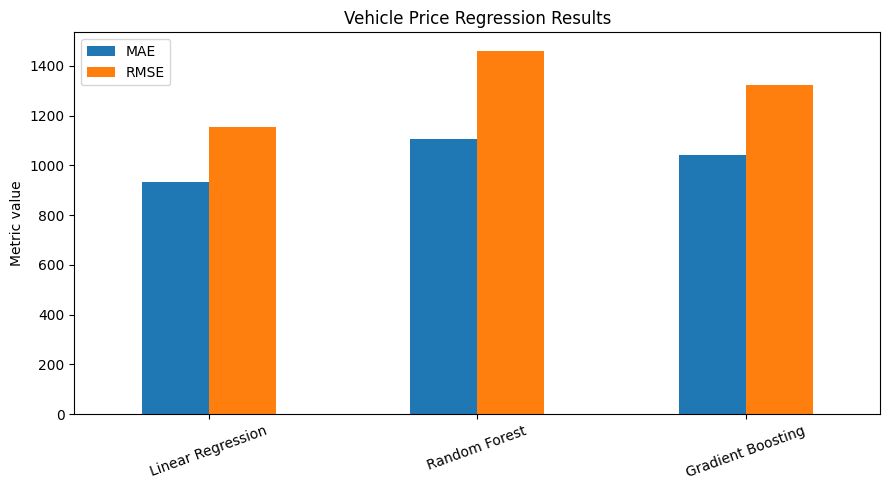

In [5]:
fig, ax = plt.subplots(figsize=(9,5))
results_df[["MAE","RMSE"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Metric value")
ax.set_title("Vehicle Price Regression Results")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

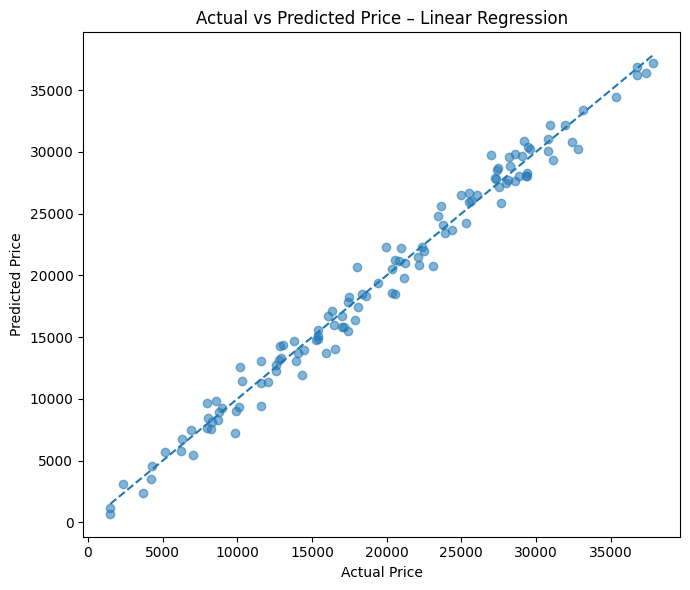

Best model by RMSE: Linear Regression


In [6]:
best_name = results_df["RMSE"].idxmin()
best_preds = predictions[best_name]

plt.figure(figsize=(7,6))
plt.scatter(y_test, best_preds, alpha=0.55)
lo, hi = y_test.min(), y_test.max()
plt.plot([lo,hi], [lo,hi], linestyle="--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted Price – {best_name}")
plt.tight_layout()
plt.show()

print("Best model by RMSE:", best_name)